## Intro

__Summary of the experiment__: BW25113 + pAR305 (Cra sensor) in M9+0.5% Mannose at 37 C. In the same experiment, there is the ∆ptsG + pAR305 in Mannose and both strains in 0.5% glucose.  __Repeat #1.__


_Imaging conditions:_ YFP channel ?%, xx ms exposure, xx gain; same? for the CFP channel. Fluorescent channel pictures were aligned to brightfield manually.


__What this script does__: plotting the fluorescent ratios CFP/YFP from the dataframe (saved as `.pkl` file). using the bandpass-filtered values, mean fluorescence. 


__elab entry:__ https://elabjournal.rug.nl/members/experiments/browser/#view=experiment&nodeID=411900&page=0&userID=0&status=0&column=created&order=DESC&search=



__Starting date of the analysis:__ 2025.05.22

In [1]:
from datetime import datetime

time = datetime.now().strftime("%d/%m/%Y %H:%M:%S")
print("Notebook started running on: ", time)

Notebook started running on:  03/07/2025 16:57:08


In [2]:
## Define inputs
path_base = r'/Users/eduardmrug/Documents/Honours research/Labwork/Experiments/20250527_MKO305/'
path_imgs = path_base + r"tifffiles"
path_mj = path_base + r"microbej"

path_out = path_base + r"/Analysis/"

folders = ["01_masks", "02_preprocessing", "03_plots"]

#### 0.1. Import packages

In [3]:
import glob
import os
import time
import pims 
import pandas as pd
import numpy as np
import trackpy as tp
import seaborn as sns
import _pickle as pickle
import skimage.io
import skimage.morphology
import scipy.io as sio
from scipy import ndimage, stats
from matplotlib import animation
import matplotlib.pyplot as plt
from pathlib import Path

In [4]:
## Module versions:
from importlib.metadata import version

modules = ["pandas", "seaborn", "matplotlib", "numpy", "scipy", "scikit-image", "pims", "trackpy"]

for m in modules:
    print("{}: ".format(m)+ version(m))

pandas: 2.2.3
seaborn: 0.13.2
matplotlib: 3.10.3
numpy: 2.2.5
scipy: 1.15.3
scikit-image: 0.25.2
pims: 0.7
trackpy: 0.6.4


#### 0.2. Define plotting settings

In [5]:
rc={"xtick.top": True, "xtick.bottom": True, "ytick.left": True, "ytick.right": True,
    "axes.spines.top": True, "axes.spines.right": True, 
    "xtick.direction": "in", "ytick.direction": "in", 
    "figure.frameon": True, "axes.grid":True,
    "grid.linestyle": ":", "grid.alpha": "0.3"}

sns.set(context="notebook", 
            style="white", palette="tab10", 
            font="sans-serif", font_scale=1.4, color_codes=False, rc=rc)

In [6]:
# Load dataframe with ratios, cell area etc. 

df_total = pd.read_pickle(os.path.join(path_out,"dataframe_fluorescence_bandpass-values.pkl"))

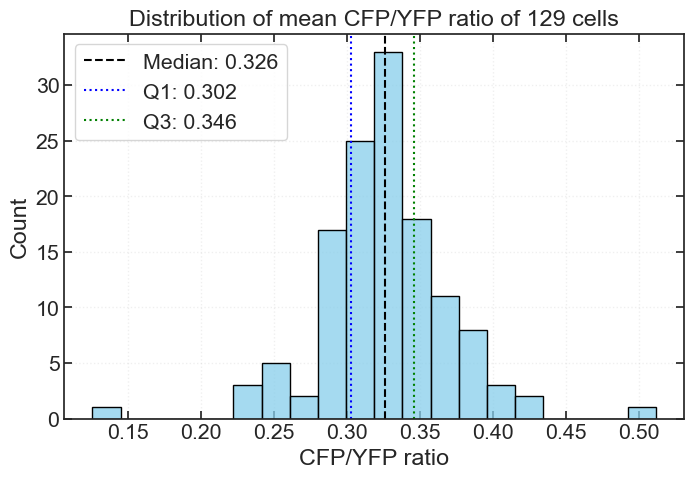

Median mean: 0.326, Q1: 0.302, Q3: 0.346


In [9]:
df_plot = df_total[df_total["ratio_mean"] <= 1]

# Filter data
df_plot = df_total[df_total["ratio_mean"] <= 1]

# Create the figure
plt.figure(figsize=(8, 5))

# Compute median and IQR for ratio_mean
median_mean = np.median(df_plot["ratio_mean"])
q1_mean = np.percentile(df_plot["ratio_mean"], 25)
q3_mean = np.percentile(df_plot["ratio_mean"], 75)

# Plot histogram
sns.histplot(df_plot["ratio_mean"], bins=20, color="skyblue", edgecolor="black")

# Plot vertical lines for median and IQR
plt.axvline(median_mean, linestyle="--", color="black", label=f"Median: {median_mean:.3f}")
plt.axvline(q1_mean, linestyle=":", color="blue", label=f"Q1: {q1_mean:.3f}")
plt.axvline(q3_mean, linestyle=":", color="green", label=f"Q3: {q3_mean:.3f}")

# Legend and x axis
plt.legend(loc="upper left")
plt.xlabel('CFP/YFP ratio')
plt.title(f'Distribution of mean CFP/YFP ratio of {len(df_plot)} cells')
# Save the plot
plt.savefig(os.path.join(path_out, "03_plots", f"Final_ratio_mean_distribution.png"))
plt.show()

print(f"Median mean: {median_mean:.3f}, Q1: {q1_mean:.3f}, Q3: {q3_mean:.3f}")


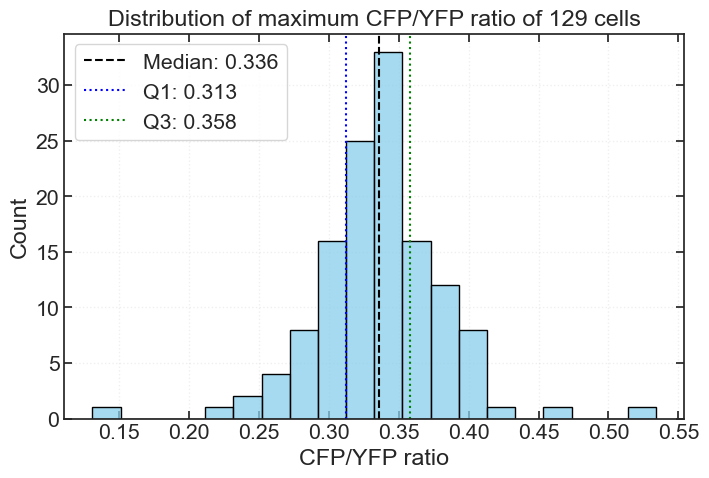

Median max: 0.336, Q1: 0.313, Q3: 0.358


In [10]:
df_plot = df_total[df_total["ratio_max"] <= 1]

# Filter data
df_plot = df_total[df_total["ratio_max"] <= 1]

# Create the figure
plt.figure(figsize=(8, 5))

# Compute median and IQR for ratio_max
median_max = np.median(df_plot["ratio_max"])
q1_max = np.percentile(df_plot["ratio_max"], 25)
q3_max = np.percentile(df_plot["ratio_max"], 75)

# Plot histogram
sns.histplot(df_plot["ratio_max"], bins=20, color="skyblue", edgecolor="black")

# Plot vertical lines for median and IQR
plt.axvline(median_max, linestyle="--", color="black", label=f"Median: {median_max:.3f}")
plt.axvline(q1_max, linestyle=":", color="blue", label=f"Q1: {q1_max:.3f}")
plt.axvline(q3_max, linestyle=":", color="green", label=f"Q3: {q3_max:.3f}")

# Legend and x axis
plt.legend(loc="upper left")
plt.xlabel('CFP/YFP ratio')
plt.title(f'Distribution of maximum CFP/YFP ratio of {len(df_plot)} cells')
# Save the plot
plt.savefig(os.path.join(path_out, "03_plots", f"Final_ratio_max_distribution.png"))
plt.show()

print(f"Median max: {median_max:.3f}, Q1: {q1_max:.3f}, Q3: {q3_max:.3f}")

#### 1.1. Import .tifs

In [8]:
all_tif = glob.glob(os.path.join(path_imgs, "*.tiff"))

In [9]:
all_tif = [x for x in all_tif ] # if ("_bf" in x)]  # only BF .tif files

In [10]:
images = {}
for path in all_tif:
    fname = aux.get_basename(path)
    images[fname] = skimage.io.imread(path)

NameError: name 'aux' is not defined

In [11]:
images.keys()

dict_keys([])

#### 1.2. Import microbeJ results

In [ ]:
all_mj = glob.glob(os.path.join(path_mj, "*.mat"))

In [ ]:
mj = {}
for path in all_mj:
    fname = aux.get_basename(path)
    print(fname)
    df_mj = sio.loadmat(path, simplify_cells=True)
    mj[fname] = df_mj["Experiment"]

#### 1.3. Establish correspondence with MicrobeJ results

In [ ]:
#changed the code to establish correspondence to my file naming system. 
#Difference is that it looks for the complete path names instead of only the stems
correspondence = {}

for mat_file in all_mj:
    mat_base = Path(mat_file).stem.lower()  # e.g. "mwt305_01"

    for tifname in images.keys():
        tif_base = Path(tifname).stem.lower()  # e.g. "20250514_mwt305_01"

        if mat_base in tif_base:
            correspondence[tifname] = mat_file

correspondence

In [ ]:
# all_mj = [x for x in all_mj]   

# correspondence = {}

# for i, fname in enumerate(all_mj):
#     fname = aux.get_basename(fname)
#     try:
#         strain, cond, sample = fname.split("_", 2) #csource, 
        
#         strain = strain.lower()
#         cond = cond.lower()
# #         csource = csource.lower()
#         sample = sample.lower()
        
#         for tifname in images.keys():
#             tifnamel = tifname.lower()
#             if  (cond in tifnamel) and ("_"+sample in tifnamel):  # (strain in tifnamel) and (csource in tifnamel) and 

#                 correspondence[tifname] = fname
                
#     except:
#         strain, cond, sample = fname.split("_", 2)
#         strain = strain.lower()
#         cond = cond.lower()
#         sample = sample.lower()
        
#         for tifname in images.keys():
#             tifnamel = tifname.lower()
            
#             if (strain in tifnamel) and (cond+"_" in tifnamel) and ("_"+sample in tifnamel):
#                 correspondence[tifname] = fname   
                
            
# correspondence

#### 1.4. Store info in Image()

In [ ]:
for img in images:
    print(img, images[img].shape)

In [ ]:
to_ignore = [""]

In [ ]:
imglist = []

for tif, mat in correspondence.items():
    if tif not in to_ignore:
        img_i = im.Image()
                
        infodict = {"um_pixel": 0.064,
                    "channels": {"bf": 0,
                                 "cfp": 1,
                                 "yfp": 2}}

        img_i.stack_raw = (images[tif], "xyc")  #  workaround to import a single frame (2021.01.26)
        
        
        infodict["name"] = tif
        print(tif)
        img_i.info = infodict
        img_i.microbej = mj[Path(mat).stem] # changed line here to only use the stem instead of whole path
        img_i.inspect_data()
        imglist.append(img_i)

In [ ]:
for img_i in imglist:
    print(img_i.info)
    print("")

#### 4.1. Quantify area of each mask (using `skimage`)

In [ ]:
####################
data_to_store = "bandpass"
####################


props = ["label", "area", "mean_intensity", "max_intensity"]

for img_i in imglist:
    img_i.quantify_fluorescence(data_to_store, props, t=0)

In [ ]:
df_total = pd.DataFrame({})
for img_i in imglist:
    df_total = store_results(img_i, df_total, data_to_store)
df_total

#### 4.2. Add new columns to dataframe

In [ ]:
#not doing this here because I don't have more conditions
################ Input #########################
# df_total["Condition"] = "None"   
# df_total.loc[df_total["image"].str.contains("_46C_"), "Condition"] = "46C"

# df_total["Strain"] = "None"   
# df_total.loc[df_total["image"].str.contains("-WT+"), "Strain"] = "WT"
# df_total
################################################

#### 4.3. Retrieve area, length and (mean) width from _MicrobeJ_

In [ ]:
df_total["area_mj"] = 0
df_total["length_mj"] = 0
df_total["width_mj"] = 0

In [ ]:
for img_i in imglist:
    all_results = img_i.microbej["Bacteria"]
    name = img_i.info["name"]
    
    for i, bb in enumerate(all_results):
        assert bb["NAME"]["name"] == img_i.cell_ids[i+1]  # check the if the ID of the cell being analyzed is correct
        
        a_bacteria = bb["SHAPE"]["area"] 
        l_bacteria = bb["SHAPE"]["length"]
        w_bacteria = bb["SHAPE"]["width"]["mean"]
        type_bacteria = bb["TYPE"]["label"]
        
        df_total.loc[(df_total["cell no."]==i+1) & (df_total["image"]==name), "area_mj"] = a_bacteria
        df_total.loc[(df_total["cell no."]==i+1) & (df_total["image"]==name), "length_mj"] = l_bacteria
        df_total.loc[(df_total["cell no."]==i+1) & (df_total["image"]==name), "width_mj"] = w_bacteria
        df_total.loc[(df_total["cell no."]==i+1) & (df_total["image"]==name), "type_mj"] = type_bacteria
        
df_total

In [ ]:
df_total["ratio_max"] = df_total["max_cfp"] / df_total["max_yfp"]
df_total["ratio_mean"] = df_total["mean_cfp"] / df_total["mean_yfp"]
df_total

#### 4.3. Save to pickle

In [ ]:
with open("{}dataframe_fluorescence_{}-values.pkl".format(path_out, data_to_store), "wb") as output:
    pickle.dump(df_total, output, -1)

## END

In [ ]:
time = datetime.now().strftime("%d/%m/%Y %H:%M:%S")
print("Notebook finished running on: ", time)